# TruthSeeker Tweet Pattern Analysis With Corrected Labels

This notebook repeats the same tweet-count analysis for two datasets:
- the original `manual_labels.json`
- a corrected copy where texts listed in `classified_labels.csv` use `pred_label`

Framework mapping used here:
- `framework1_feature1` = `central`
- `framework1_feature2` = `peripheral`


In [1]:
import json
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

try:
    import seaborn as sns
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch
    sns.set_theme(style='whitegrid', context='talk')
    HAS_PLOTTING = True
except Exception as e:
    HAS_PLOTTING = False
    PLOTTING_ERROR = str(e)

try:
    import statsmodels.formula.api as smf
    from statsmodels.stats.anova import anova_lm
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False

try:
    from scipy import stats
    HAS_SCIPY = True
except ImportError:
    HAS_SCIPY = False

ROOT = Path('.')
ORIGINAL_PATH = ROOT / 'manual_labels.json'
CORRECTED_PATH = ROOT / 'classified_labels.json'
PALETTE = {
    'health': '#B7D7F0',
    'technology': '#C8B6E2',
    'framework1_feature1': '#A8D8B9',
    'framework1_feature2': '#D8C4F1',
    'manual': '#AFCBEA',
    'classified': '#BFE3C0',
}
COMBO_PALETTE = ['#B7D7F0', '#C8B6E2', '#A8D8B9', '#D8C4F1']
if HAS_PLOTTING:
    plt.rcParams['figure.facecolor'] = 'white'
    plt.rcParams['axes.facecolor'] = '#FCFCFF'
    plt.rcParams['axes.edgecolor'] = '#D7DBE6'
    plt.rcParams['grid.color'] = '#E7EBF3'
    plt.rcParams['axes.titleweight'] = 'semibold'
    plt.rcParams['axes.titlesize'] = 16
    plt.rcParams['axes.labelsize'] = 12


In [2]:
def label_framework(row):
    f1 = int(row['framework1_feature1'])
    f2 = int(row['framework1_feature2'])
    if f1 == 1 and f2 == 0:
        return 'framework1_feature1'
    if f1 == 0 and f2 == 1:
        return 'framework1_feature2'
    if f1 == 1 and f2 == 1:
        return 'both'
    return 'neither'

def cliffs_delta(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    gt = sum((xi > y).sum() for xi in x)
    lt = sum((xi < y).sum() for xi in x)
    return (gt - lt) / (len(x) * len(y))

def permutation_test_median(x, y, n_resamples=5000, seed=42):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    observed = abs(np.median(x) - np.median(y))
    combined = np.concatenate([x, y])
    n_x = len(x)
    rng = np.random.default_rng(seed)
    extreme = 0

    for _ in range(n_resamples):
        shuffled = rng.permutation(combined)
        x_perm = shuffled[:n_x]
        y_perm = shuffled[n_x:]
        stat = abs(np.median(x_perm) - np.median(y_perm))
        if stat >= observed:
            extreme += 1

    return (extreme + 1) / (n_resamples + 1)

def compare_groups(frame, filter_a, filter_b, label_a, label_b):
    a = frame.loc[filter_a, 'no_of_tweets'].dropna()
    b = frame.loc[filter_b, 'no_of_tweets'].dropna()
    if len(a) < 2 or len(b) < 2:
        return {
            'comparison': f'{label_a} vs {label_b}',
            'n_a': len(a),
            'n_b': len(b),
            'median_a': a.median() if len(a) else np.nan,
            'median_b': b.median() if len(b) else np.nan,
            'mean_a': a.mean() if len(a) else np.nan,
            'mean_b': b.mean() if len(b) else np.nan,
            'permutation_p': np.nan,
            'cliffs_delta': np.nan,
            'direction': 'insufficient data'
        }

    p_value = permutation_test_median(a.values, b.values)
    delta = cliffs_delta(a.values, b.values)
    median_a = a.median()
    median_b = b.median()

    if median_a > median_b:
        direction = f'{label_a} tends to have higher tweets'
    elif median_b > median_a:
        direction = f'{label_b} tends to have higher tweets'
    else:
        direction = 'medians are equal'

    return {
        'comparison': f'{label_a} vs {label_b}',
        'n_a': len(a),
        'n_b': len(b),
        'median_a': median_a,
        'median_b': median_b,
        'mean_a': a.mean(),
        'mean_b': b.mean(),
        'permutation_p': p_value,
        'cliffs_delta': delta,
        'direction': direction
    }

def interpret_delta(delta):
    abs_delta = abs(delta)
    if abs_delta < 0.147:
        return 'negligible'
    if abs_delta < 0.33:
        return 'small'
    if abs_delta < 0.474:
        return 'medium'
    return 'large'


In [3]:
def prepare_analysis_frame(data_path):
    with open(data_path, 'r', encoding='utf-8') as f:
        records = json.load(f)
    df = pd.DataFrame(records).copy()
    df['topic'] = df['topic'].str.lower().str.strip()
    df['no_of_tweets'] = pd.to_numeric(df['no_of_tweets'], errors='coerce')
    df['framework_group'] = df.apply(label_framework, axis=1)
    analysis_df = df[df['framework_group'].isin(['framework1_feature1', 'framework1_feature2'])].copy()
    analysis_df['framework_label'] = analysis_df['framework_group'].replace({'framework1_feature1': 'central', 'framework1_feature2': 'peripheral'})
    analysis_df['topic_framework'] = analysis_df['topic'].str.title() + ' | ' + analysis_df['framework_label'].str.title()
    return df, analysis_df

def holm_adjust(p_values):
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    adjusted = np.empty(len(p_values), dtype=float)
    running_max = 0.0
    m = len(p_values)
    for rank, idx in enumerate(order):
        adjusted_value = (m - rank) * p_values[idx]
        running_max = max(running_max, adjusted_value)
        adjusted[idx] = min(running_max, 1.0)
    return adjusted

def compare_four_groups(analysis_df):
    labels = ['Health | Central', 'Health | Peripheral', 'Technology | Central', 'Technology | Peripheral']
    group_values = {label: analysis_df.loc[analysis_df['topic_framework'] == label, 'no_of_tweets'].dropna().values for label in labels}
    overall = {'test': 'not run', 'statistic': np.nan, 'p_value': np.nan}
    if HAS_SCIPY and all(len(group_values[label]) >= 2 for label in labels):
        statistic, p_value = stats.kruskal(*(group_values[label] for label in labels))
        overall = {'test': 'Kruskal-Wallis', 'statistic': statistic, 'p_value': p_value}

    pairwise_rows = []
    for i, label_a in enumerate(labels):
        for label_b in labels[i + 1:]:
            row = compare_groups(
                analysis_df,
                analysis_df['topic_framework'] == label_a,
                analysis_df['topic_framework'] == label_b,
                label_a,
                label_b,
            )
            pairwise_rows.append(row)
    pairwise_df = pd.DataFrame(pairwise_rows)
    if len(pairwise_df):
        pairwise_df['holm_p'] = holm_adjust(pairwise_df['permutation_p'].fillna(1.0).values)
        pairwise_df['significant_holm_0_05'] = pairwise_df['holm_p'] < 0.05
        pairwise_df['effect_size'] = pairwise_df['cliffs_delta'].apply(lambda x: interpret_delta(x) if pd.notna(x) else 'n/a')
        pairwise_df['permutation_p'] = pairwise_df['permutation_p'].round(4)
        pairwise_df['holm_p'] = pairwise_df['holm_p'].round(4)
        pairwise_df['cliffs_delta'] = pairwise_df['cliffs_delta'].round(3)
    return overall, pairwise_df

def balanced_resampled_medians(analysis_df, n_resamples=2000, seed=42):
    labels = ['Health | Central', 'Health | Peripheral', 'Technology | Central', 'Technology | Peripheral']
    groups = {
        label: analysis_df.loc[analysis_df['topic_framework'] == label, 'no_of_tweets'].dropna().to_numpy()
        for label in labels
    }
    group_sizes = {label: len(values) for label, values in groups.items()}
    min_n = min(group_sizes.values()) if group_sizes else 0
    if min_n < 2:
        return pd.DataFrame(), {'balanced_n': min_n, 'group_sizes': group_sizes, 'n_resamples': 0}
    rng = np.random.default_rng(seed)
    rows = []
    for label in labels:
        values = groups[label]
        for resample_idx in range(n_resamples):
            sampled = rng.choice(values, size=min_n, replace=False)
            rows.append({'topic_framework': label, 'resample_idx': resample_idx, 'median_tweets': float(np.median(sampled))})
    return pd.DataFrame(rows), {'balanced_n': min_n, 'group_sizes': group_sizes, 'n_resamples': n_resamples}

def run_analysis(data_path, dataset_name):
    print(f'===== {dataset_name} =====')
    df, analysis_df = prepare_analysis_frame(data_path)

    print(f'Rows in dataset: {len(df)}')
    print(f'Rows in analysis subset: {len(analysis_df)}')
    summary_by_topic = analysis_df.groupby('topic')['no_of_tweets'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).sort_values('median', ascending=False)
    summary_by_framework = analysis_df.groupby('framework_label')['no_of_tweets'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).sort_values('median', ascending=False)
    summary_topic_framework = analysis_df.groupby('topic_framework')['no_of_tweets'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).sort_values('median', ascending=False)
    print('\n## Research question 1: Health vs Technology')
    display(summary_by_topic)
    print('\n## Research question 2: Central vs Peripheral')
    display(summary_by_framework)
    print('\n## Research question 3: The four-group comparison')
    display(summary_topic_framework)

    if HAS_PLOTTING:
        plt.figure(figsize=(6.2, 4.8))
        sns.boxplot(data=analysis_df, x='topic', y='no_of_tweets', palette=PALETTE, showfliers=False, linewidth=1.4)
        plt.title(f'Health vs Technology ({dataset_name})')
        plt.xlabel('Topic')
        plt.ylabel('no_of_tweets')
        plt.tight_layout()
        plt.show()

        topic_medians = analysis_df.groupby('topic', as_index=False)['no_of_tweets'].median()
        plt.figure(figsize=(6.0, 4.6))
        sns.barplot(data=topic_medians, x='topic', y='no_of_tweets', palette=PALETTE)
        plt.title(f'Median Tweet Count by Topic ({dataset_name})')
        plt.xlabel('Topic')
        plt.ylabel('Median no_of_tweets')
        ax = plt.gca()
        for container in ax.containers:
            ax.bar_label(container, fmt='%.0f', padding=3, fontsize=10)
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(6.2, 4.8))
        sns.boxplot(data=analysis_df, x='framework_label', y='no_of_tweets', palette={'central': PALETTE['framework1_feature1'], 'peripheral': PALETTE['framework1_feature2']}, showfliers=False, linewidth=1.4)
        plt.title(f'Central vs Peripheral ({dataset_name})')
        plt.xlabel('Framework Group')
        plt.ylabel('no_of_tweets')
        plt.tight_layout()
        plt.show()

        framework_medians = analysis_df.groupby('framework_label', as_index=False)['no_of_tweets'].median()
        plt.figure(figsize=(6.0, 4.6))
        sns.barplot(data=framework_medians, x='framework_label', y='no_of_tweets', palette={'central': PALETTE['framework1_feature1'], 'peripheral': PALETTE['framework1_feature2']})
        plt.title(f'Median Tweet Count by Framework Group ({dataset_name})')
        plt.xlabel('Framework Group')
        plt.ylabel('Median no_of_tweets')
        ax = plt.gca()
        for container in ax.containers:
            ax.bar_label(container, fmt='%.0f', padding=3, fontsize=10)
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(7.2, 5.2))
        order = ['Health | Central', 'Health | Peripheral', 'Technology | Central', 'Technology | Peripheral']
        sns.boxplot(data=analysis_df, x='topic_framework', y='no_of_tweets', order=order, palette=COMBO_PALETTE, showfliers=False, linewidth=1.4)
        plt.title(f'Four-Group Tweet Count Comparison ({dataset_name})')
        plt.xlabel('Group')
        plt.ylabel('no_of_tweets')
        plt.xticks(rotation=18, ha='right')
        plt.tight_layout()
        plt.show()

        four_group_medians = analysis_df.groupby('topic_framework', as_index=False)['no_of_tweets'].median()
        four_group_medians['topic_framework'] = pd.Categorical(four_group_medians['topic_framework'], categories=['Health | Central', 'Health | Peripheral', 'Technology | Central', 'Technology | Peripheral'], ordered=True)
        four_group_medians = four_group_medians.sort_values('topic_framework')
        plt.figure(figsize=(7.0, 4.8))
        sns.barplot(data=four_group_medians, x='topic_framework', y='no_of_tweets', palette=COMBO_PALETTE)
        plt.title(f'Median Tweet Count Across the Four Groups ({dataset_name})')
        plt.xlabel('Group')
        plt.ylabel('Median no_of_tweets')
        plt.xticks(rotation=18, ha='right')
        ax = plt.gca()
        for container in ax.containers:
            ax.bar_label(container, fmt='%.0f', padding=3, fontsize=10)
        plt.tight_layout()
        plt.show()
    else:
        print(f'Plotting skipped: {PLOTTING_ERROR}')

    comparisons = []
    comparisons.append(compare_groups(analysis_df, analysis_df['topic'] == 'health', analysis_df['topic'] == 'technology', 'health', 'technology'))
    comparisons.append(compare_groups(analysis_df, analysis_df['framework_label'] == 'central', analysis_df['framework_label'] == 'peripheral', 'central', 'peripheral'))
    comparisons.append(compare_groups(analysis_df, (analysis_df['topic'] == 'health') & (analysis_df['framework_label'] == 'central'), (analysis_df['topic'] == 'health') & (analysis_df['framework_label'] == 'peripheral'), 'health central', 'health peripheral'))
    comparisons.append(compare_groups(analysis_df, (analysis_df['topic'] == 'technology') & (analysis_df['framework_label'] == 'central'), (analysis_df['topic'] == 'technology') & (analysis_df['framework_label'] == 'peripheral'), 'technology central', 'technology peripheral'))
    comparisons.append(compare_groups(analysis_df, (analysis_df['topic'] == 'health') & (analysis_df['framework_label'] == 'central'), (analysis_df['topic'] == 'technology') & (analysis_df['framework_label'] == 'central'), 'health central', 'technology central'))
    comparisons.append(compare_groups(analysis_df, (analysis_df['topic'] == 'health') & (analysis_df['framework_label'] == 'peripheral'), (analysis_df['topic'] == 'technology') & (analysis_df['framework_label'] == 'peripheral'), 'health peripheral', 'technology peripheral'))
    comparison_df = pd.DataFrame(comparisons)
    comparison_df['significant_0_05'] = comparison_df['permutation_p'] < 0.05
    interpreted = comparison_df.copy()
    interpreted['effect_size'] = interpreted['cliffs_delta'].apply(lambda x: interpret_delta(x) if pd.notna(x) else 'n/a')
    interpreted['permutation_p'] = interpreted['permutation_p'].round(4)
    interpreted['cliffs_delta'] = interpreted['cliffs_delta'].round(3)
    print('\n## Direct pairwise tests for the research questions')
    display(interpreted[['comparison', 'n_a', 'n_b', 'median_a', 'median_b', 'mean_a', 'mean_b', 'permutation_p', 'cliffs_delta', 'effect_size', 'significant_0_05', 'direction']].sort_values('permutation_p'))

    overall_four_group, four_group_pairwise = compare_four_groups(analysis_df)
    balanced_resamples, balanced_meta = balanced_resampled_medians(analysis_df)
    print('\n## Overall four-group test')
    display(pd.DataFrame([overall_four_group]))
    print('\n## Four-group follow-up pairwise comparisons')
    display(four_group_pairwise[['comparison', 'n_a', 'n_b', 'median_a', 'median_b', 'permutation_p', 'holm_p', 'cliffs_delta', 'effect_size', 'significant_holm_0_05', 'direction']].sort_values(['holm_p', 'permutation_p']))

    print('\n## Balanced-resampling check for unequal group sizes')
    print(f"Using {balanced_meta['balanced_n']} claims per group in each resample.")
    display(pd.DataFrame([balanced_meta]))
    if len(balanced_resamples):
        display(balanced_resamples.groupby('topic_framework')['median_tweets'].agg(['mean', 'median', 'std', 'min', 'max']).round(2))

        if HAS_PLOTTING:
            plt.figure(figsize=(7.2, 5.2))
            order = ['Health | Central', 'Health | Peripheral', 'Technology | Central', 'Technology | Peripheral']
            sns.violinplot(data=balanced_resamples, x='topic_framework', y='median_tweets', order=order, palette=COMBO_PALETTE, inner='quartile', linewidth=1.1, cut=0)
            plt.title(f'Balanced Resampling of Four-Group Medians ({dataset_name})')
            plt.xlabel('Group')
            plt.ylabel('Median no_of_tweets in equal-sized resamples (log scale)')
            plt.yscale('log')
            plt.xticks(rotation=18, ha='right')
            plt.tight_layout()
            plt.show()

    if HAS_STATSMODELS:
        analysis_df = analysis_df.copy()
        analysis_df['log_no_of_tweets'] = np.log1p(analysis_df['no_of_tweets'])
        print('\n## Optional model-based interaction test on log counts')
        model = smf.ols('log_no_of_tweets ~ C(topic) * C(framework_label)', data=analysis_df).fit()
        display(model.summary())
        display(anova_lm(model, typ=2))
    else:
        print('\nstatsmodels is not installed, so the optional interaction regression was skipped.')

    topic_medians = analysis_df.groupby('topic')['no_of_tweets'].median().sort_values(ascending=False)
    framework_medians = analysis_df.groupby('framework_label')['no_of_tweets'].median().sort_values(ascending=False)
    four_group_medians = summary_topic_framework['median'].sort_values(ascending=False)
    print('\n## Auto-generated takeaways aligned to the research question')
    print('1. Topic pattern')
    print(f"   {topic_medians.index[0]} has the higher median tweet count ({topic_medians.iloc[0]:.1f} vs {topic_medians.iloc[1]:.1f}).")
    print('\n2. Framework pattern')
    print(f"   {framework_medians.index[0]} has the higher median tweet count ({framework_medians.iloc[0]:.1f} vs {framework_medians.iloc[1]:.1f}).")
    print('\n3. Four-group ranking')
    for group_name, value in four_group_medians.items():
        print(f"   {group_name}: median={value:.1f}")
    print('\n4. Significant direct comparisons at p < 0.05')
    sig = interpreted[interpreted['significant_0_05']].sort_values('permutation_p')
    if len(sig) == 0:
        print('   No pairwise comparison reached the 0.05 threshold.')
    else:
        for _, row in sig.iterrows():
            print(f"   {row['comparison']}: permutation p={row['permutation_p']}, Cliff's delta={row['cliffs_delta']} ({row['effect_size']}) -> {row['direction']}")
    print('\n5. Overall four-group test')
    if pd.notna(overall_four_group['p_value']):
        print(f"   {overall_four_group['test']} p-value = {overall_four_group['p_value']:.4f}")
    else:
        print('   Overall four-group test was skipped due to missing SciPy or too-small groups.')

    print('6. Balanced-resampling check')
    if len(balanced_resamples):
        resampled_rank = balanced_resamples.groupby('topic_framework')['median_tweets'].median().sort_values(ascending=False)
        print(f"   Each group was repeatedly resampled down to n={balanced_meta['balanced_n']} claims.")
        for group_name, value in resampled_rank.items():
            print(f"   {group_name}: resampled median={value:.1f}")
    else:
        print('   Balanced resampling was skipped because at least one group had fewer than 2 claims.')

    return {
        'dataset_name': dataset_name,
        'summary_by_topic': summary_by_topic,
        'summary_by_framework': summary_by_framework,
        'summary_topic_framework': summary_topic_framework,
        'comparison_df': comparison_df,
        'interpreted': interpreted,
        'overall_four_group': overall_four_group,
        'four_group_pairwise': four_group_pairwise,
        'balanced_resamples': balanced_resamples,
        'balanced_meta': balanced_meta,
        'analysis_df': analysis_df,
    }


## Manual dataset

===== Manual labels =====
Rows in dataset: 174
Rows in analysis subset: 174

## Research question 1: Health vs Technology


,count,mean,median,std,min,max
topic,,,,,,
health,141,147.567376,42.0,184.955450,1,490
technology,33,75.606061,12.0,134.111646,1,471



## Research question 2: Central vs Peripheral


,count,mean,median,std,min,max
framework_label,,,,,,
peripheral,117,164.341880,49.0,192.882766,1,490
central,57,71.473684,18.0,123.709641,1,485



## Research question 3: The four-group comparison


,count,mean,median,std,min,max
topic_framework,,,,,,
Health | Peripheral,93,182.333333,53.0,198.969046,1,490
Health | Central,48,80.208333,20.5,131.831607,1,485
Technology | Peripheral,24,94.625000,18.0,151.330853,2,471
Technology | Central,9,24.888889,7.0,46.090792,1,146


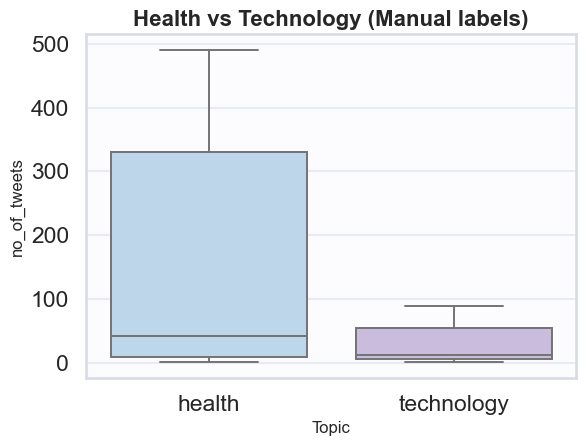

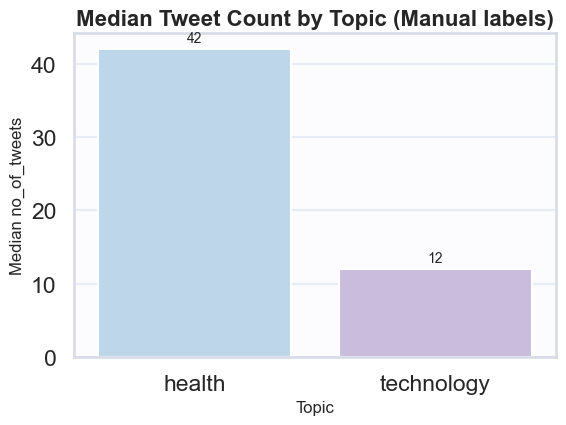

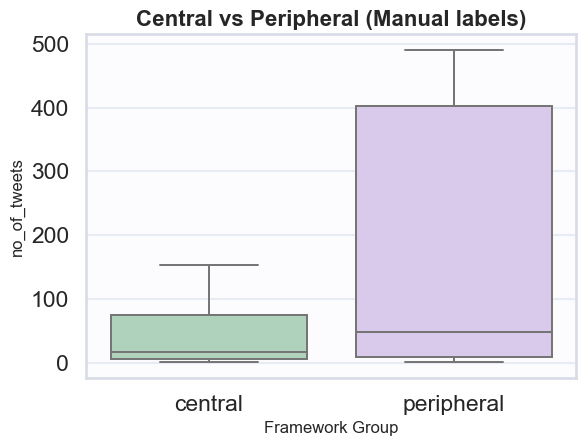

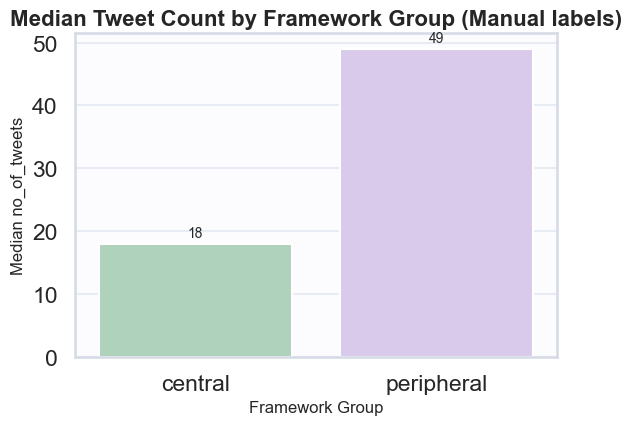

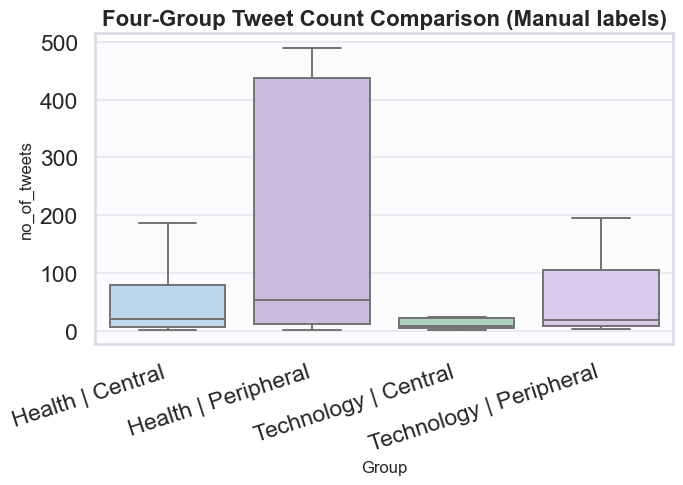

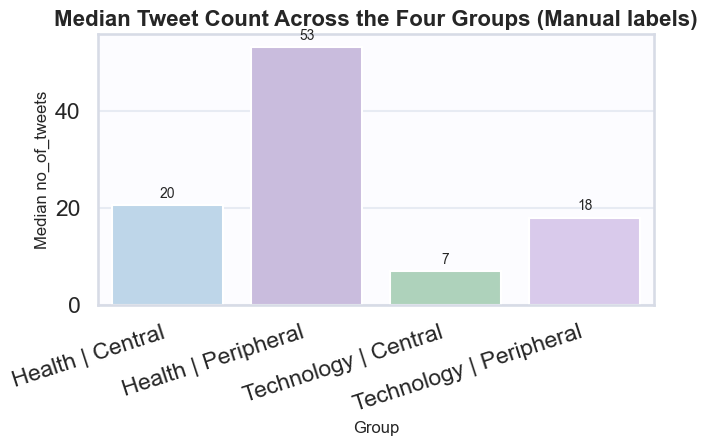


## Direct pairwise tests for the research questions


,comparison,n_a,n_b,median_a,median_b,mean_a,mean_b,permutation_p,cliffs_delta,effect_size,significant_0_05,direction
1,central vs peripheral,57,117,18.0,49.0,71.473684,164.341880,0.0808,-0.255,small,False,peripheral tends to have higher tweets
0,health vs technology,141,33,42.0,12.0,147.567376,75.606061,0.1532,0.238,small,False,health tends to have higher tweets
2,health central vs health peripheral,48,93,20.5,53.0,80.208333,182.333333,0.1582,-0.258,small,False,health peripheral tends to have higher tweets
5,health peripheral vs technology peripheral,93,24,53.0,18.0,182.333333,94.625000,0.2492,0.250,small,False,health peripheral tends to have higher tweets
4,health central vs technology central,48,9,20.5,7.0,80.208333,24.888889,0.3527,0.312,small,False,health central tends to have higher tweets
3,technology central vs technology peripheral,9,24,7.0,18.0,24.888889,94.625000,0.4239,-0.329,small,False,technology peripheral tends to have higher tweets



## Overall four-group test


,test,statistic,p_value
0,Kruskal-Wallis,12.674747,0.005395



## Four-group follow-up pairwise comparisons


,comparison,n_a,n_b,median_a,median_b,permutation_p,holm_p,cliffs_delta,effect_size,significant_holm_0_05,direction
0,Health | Central vs Health | Peripheral,48,93,20.5,53.0,0.1582,0.949,-0.258,small,False,Health | Peripheral tends to have higher tweets
4,Health | Peripheral vs Technology | Peripheral,93,24,53.0,18.0,0.2492,1.000,0.250,small,False,Health | Peripheral tends to have higher tweets
3,Health | Peripheral vs Technology | Central,93,9,53.0,7.0,0.3103,1.000,0.533,large,False,Health | Peripheral tends to have higher tweets
1,Health | Central vs Technology | Central,48,9,20.5,7.0,0.3527,1.000,0.312,small,False,Health | Central tends to have higher tweets
5,Technology | Central vs Technology | Peripheral,9,24,7.0,18.0,0.4239,1.000,-0.329,small,False,Technology | Peripheral tends to have higher t...
2,Health | Central vs Technology | Peripheral,48,24,20.5,18.0,0.9198,1.000,-0.026,negligible,False,Health | Central tends to have higher tweets



## Balanced-resampling check for unequal group sizes
Using 9 claims per group in each resample.


,balanced_n,group_sizes,n_resamples
0,9,"{'Health | Central': 48, 'Health | Peripheral'...",2000


,mean,median,std,min,max
topic_framework,,,,,
Health | Central,29.60,21.0,23.92,4.0,154.0
Health | Peripheral,120.59,53.0,135.85,4.0,473.0
Technology | Central,7.00,7.0,0.00,7.0,7.0
Technology | Peripheral,26.52,22.0,24.33,5.0,181.0


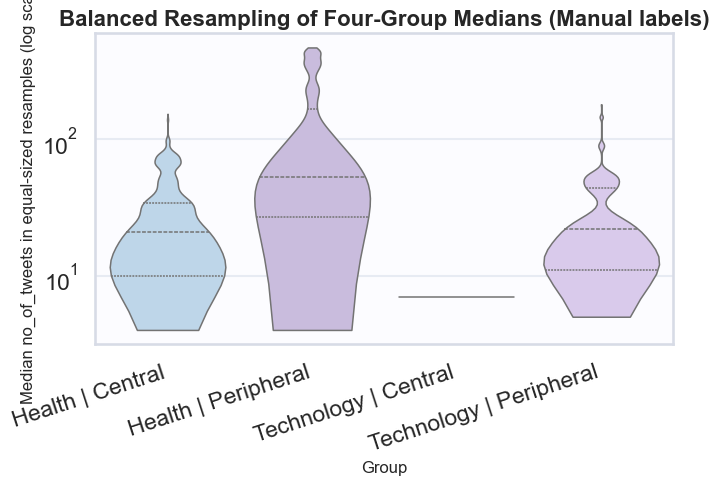


## Optional model-based interaction test on log counts


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       log_no_of_tweets   R-squared:                       0.077
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     4.736
Date:                Mon, 27 Apr 2026   Prob (F-statistic):            0.00337
Time:                        06:06:45   Log-Likelihood:                -335.10
No. Observations:                 174   AIC:                             678.2
Df Residuals:                     170   BIC:                             690.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===========================================================================================================================
                                                              coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------
Intercept                                                   3.2880      0.242     13.563      0.000       2.809       3.767
C(topic)[T.technology]                                     -0.8786      0.610     -1.440      0.152      -2.083       0.326
C(framework_label)[T.peripheral]                            0.8014      0.299      2.685      0.008       0.212       1.391
C(topic)[T.technology]:C(framework_label)[T.peripheral]     0.1407      0.721      0.195      0.846      -1.283       1.564
==============================================================================
Omnibus:                       76.344   Durbin-Watson:                   2.130
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               10.470
Skew:                           0.009   Prob(JB):                      0.00533
Kurtosis:                       1.798   Cond. No.                         9.16
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

,sum_sq,df,F,PR(>F)
C(topic),16.128328,1.0,5.717336,0.017891
C(framework_label),26.033840,1.0,9.228745,0.002759
C(topic):C(framework_label),0.107389,1.0,0.038068,0.845539
Residual,479.561737,170.0,NaN,NaN



## Auto-generated takeaways aligned to the research question
1. Topic pattern
   health has the higher median tweet count (42.0 vs 12.0).

2. Framework pattern
   peripheral has the higher median tweet count (49.0 vs 18.0).

3. Four-group ranking
   Health | Peripheral: median=53.0
   Health | Central: median=20.5
   Technology | Peripheral: median=18.0
   Technology | Central: median=7.0

4. Significant direct comparisons at p < 0.05
   No pairwise comparison reached the 0.05 threshold.

5. Overall four-group test
   Kruskal-Wallis p-value = 0.0054
6. Balanced-resampling check
   Each group was repeatedly resampled down to n=9 claims.
   Health | Peripheral: resampled median=53.0
   Technology | Peripheral: resampled median=22.0
   Health | Central: resampled median=21.0
   Technology | Central: resampled median=7.0


In [4]:
manual_results = run_analysis(ORIGINAL_PATH, 'Manual labels')

## Classified dataset

===== Classified labels from mistakes_combined_early.csv =====
Rows in dataset: 174
Rows in analysis subset: 174

## Research question 1: Health vs Technology


,count,mean,median,std,min,max
topic,,,,,,
health,141,147.567376,42.0,184.955450,1,490
technology,33,75.606061,12.0,134.111646,1,471



## Research question 2: Central vs Peripheral


,count,mean,median,std,min,max
framework_label,,,,,,
peripheral,122,149.729508,29.0,190.282132,1,490
central,52,96.826923,28.0,141.428250,1,485



## Research question 3: The four-group comparison


,count,mean,median,std,min,max
topic_framework,,,,,,
Health | Peripheral,97,164.835052,42.0,197.351668,1,490
Health | Central,44,109.500000,40.5,149.225208,1,485
Technology | Peripheral,25,91.120000,14.0,149.177556,2,471
Technology | Central,8,27.125000,8.5,48.748443,1,146


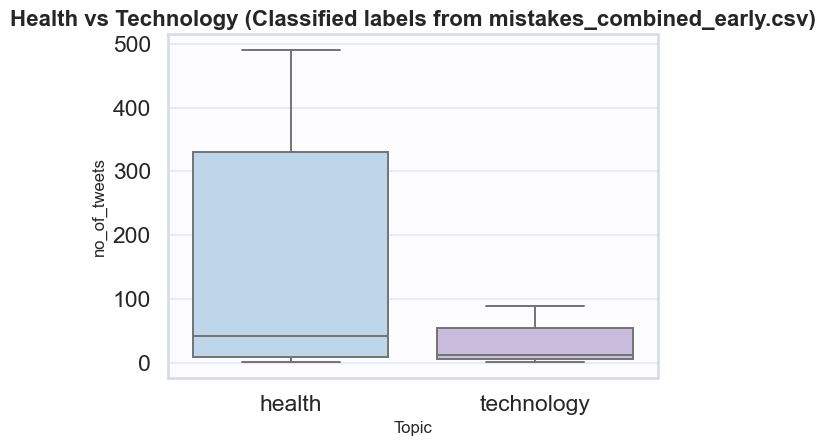

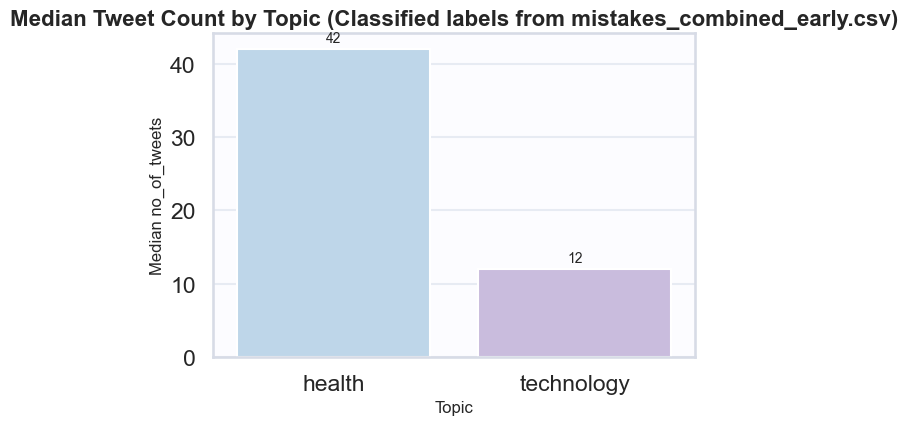

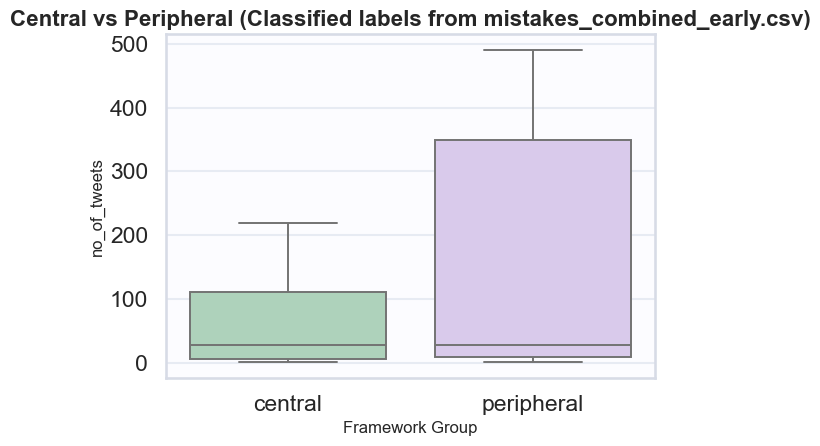

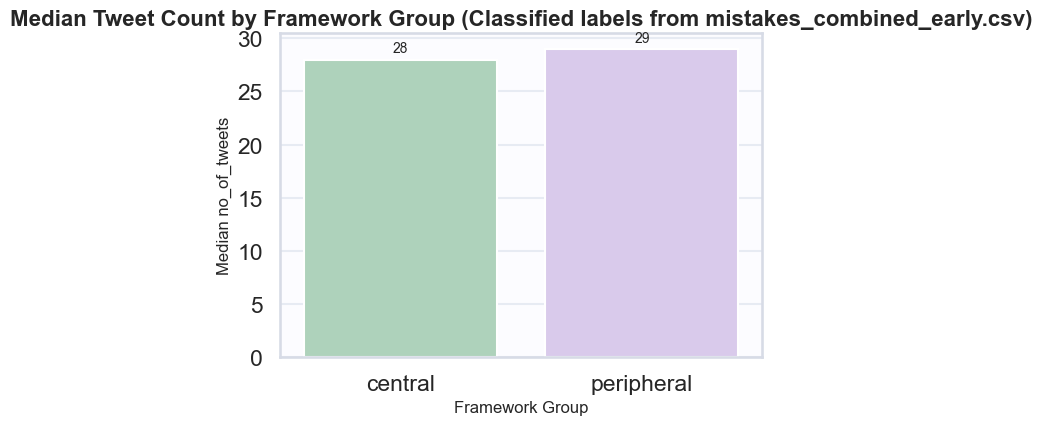

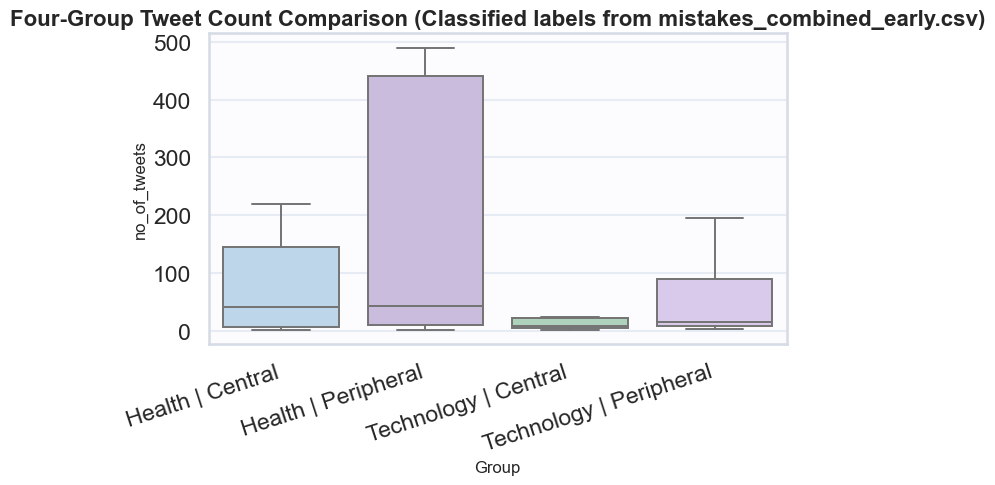

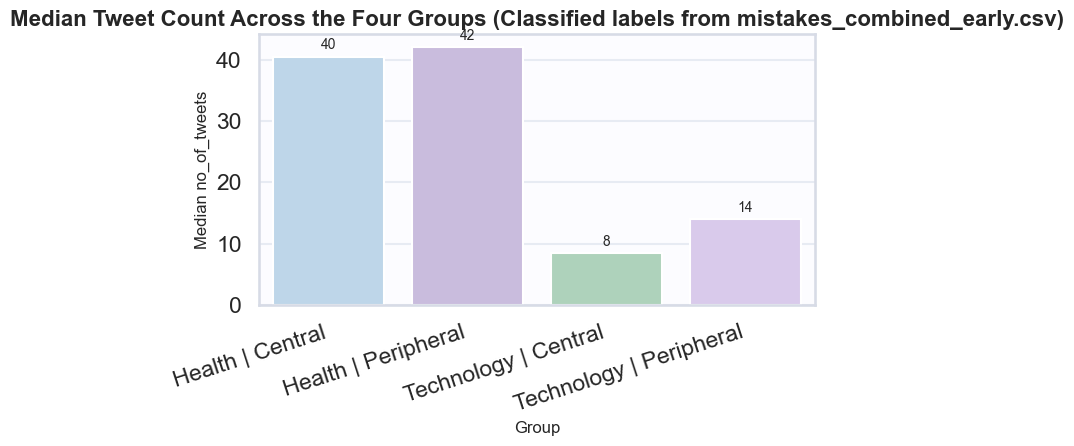


## Direct pairwise tests for the research questions


,comparison,n_a,n_b,median_a,median_b,mean_a,mean_b,permutation_p,cliffs_delta,effect_size,significant_0_05,direction
0,health vs technology,141,33,42.0,12.0,147.567376,75.606061,0.1532,0.238,small,False,health tends to have higher tweets
5,health peripheral vs technology peripheral,97,25,42.0,14.0,164.835052,91.120000,0.2795,0.215,small,False,health peripheral tends to have higher tweets
4,health central vs technology central,44,8,40.5,8.5,109.500000,27.125000,0.3151,0.389,medium,False,health central tends to have higher tweets
3,technology central vs technology peripheral,8,25,8.5,14.0,27.125000,91.120000,0.6601,-0.295,small,False,technology peripheral tends to have higher tweets
1,central vs peripheral,52,122,28.0,29.0,96.826923,149.729508,0.9562,-0.138,negligible,False,peripheral tends to have higher tweets
2,health central vs health peripheral,44,97,40.5,42.0,109.500000,164.835052,0.9616,-0.127,negligible,False,health peripheral tends to have higher tweets



## Overall four-group test


,test,statistic,p_value
0,Kruskal-Wallis,7.317984,0.062424



## Four-group follow-up pairwise comparisons


,comparison,n_a,n_b,median_a,median_b,permutation_p,holm_p,cliffs_delta,effect_size,significant_holm_0_05,direction
4,Health | Peripheral vs Technology | Peripheral,97,25,42.0,14.0,0.2795,1.0,0.215,small,False,Health | Peripheral tends to have higher tweets
1,Health | Central vs Technology | Central,44,8,40.5,8.5,0.3151,1.0,0.389,medium,False,Health | Central tends to have higher tweets
3,Health | Peripheral vs Technology | Central,97,8,42.0,8.5,0.3615,1.0,0.466,medium,False,Health | Peripheral tends to have higher tweets
2,Health | Central vs Technology | Peripheral,44,25,40.5,14.0,0.4257,1.0,0.079,negligible,False,Health | Central tends to have higher tweets
5,Technology | Central vs Technology | Peripheral,8,25,8.5,14.0,0.6601,1.0,-0.295,small,False,Technology | Peripheral tends to have higher t...
0,Health | Central vs Health | Peripheral,44,97,40.5,42.0,0.9616,1.0,-0.127,negligible,False,Health | Peripheral tends to have higher tweets



## Balanced-resampling check for unequal group sizes
Using 8 claims per group in each resample.


,balanced_n,group_sizes,n_resamples
0,8,"{'Health | Central': 44, 'Health | Peripheral'...",2000


,mean,median,std,min,max
topic_framework,,,,,
Health | Central,52.09,44.0,40.99,4.0,295.5
Health | Peripheral,98.08,44.0,113.28,2.0,473.0
Technology | Central,8.50,8.5,0.00,8.5,8.5
Technology | Peripheral,28.40,17.0,26.68,5.0,188.0


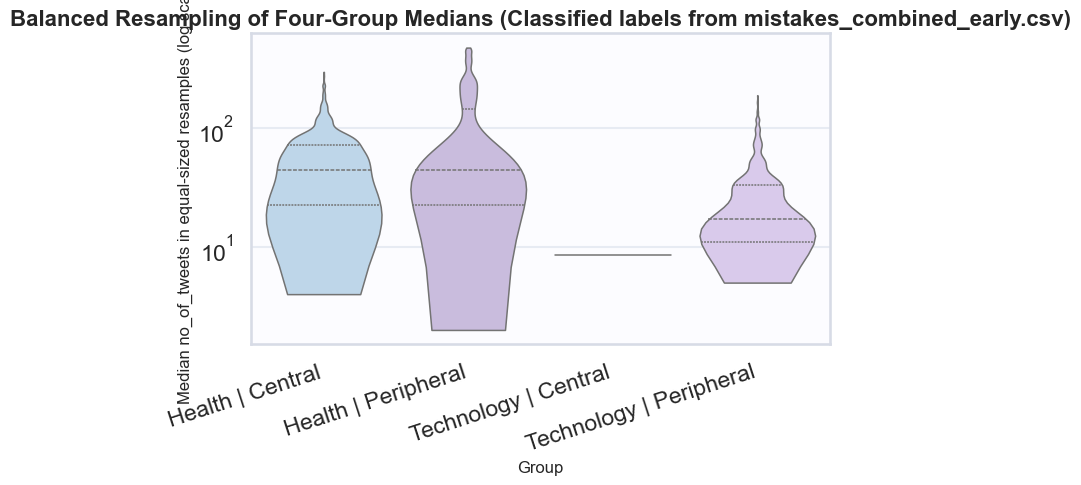


## Optional model-based interaction test on log counts


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       log_no_of_tweets   R-squared:                       0.041
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     2.419
Date:                Mon, 27 Apr 2026   Prob (F-statistic):             0.0679
Time:                        06:06:50   Log-Likelihood:                -338.44
No. Observations:                 174   AIC:                             684.9
Df Residuals:                     170   BIC:                             697.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===========================================================================================================================
                                                              coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------
Intercept                                                   3.6015      0.258     13.953      0.000       3.092       4.111
C(topic)[T.technology]                                     -1.1508      0.658     -1.749      0.082      -2.450       0.148
C(framework_label)[T.peripheral]                            0.3127      0.311      1.005      0.316      -0.302       0.927
C(topic)[T.technology]:C(framework_label)[T.peripheral]     0.5373      0.762      0.705      0.482      -0.967       2.041
==============================================================================
Omnibus:                      130.273   Durbin-Watson:                   2.130
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               12.242
Skew:                           0.074   Prob(JB):                      0.00220
Kurtosis:                       1.709   Cond. No.                         9.74
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

,sum_sq,df,F,PR(>F)
C(topic),14.987921,1.0,5.112610,0.025020
C(framework_label),5.880336,1.0,2.005873,0.158521
C(topic):C(framework_label),1.457505,1.0,0.497177,0.481708
Residual,498.365124,170.0,NaN,NaN



## Auto-generated takeaways aligned to the research question
1. Topic pattern
   health has the higher median tweet count (42.0 vs 12.0).

2. Framework pattern
   peripheral has the higher median tweet count (29.0 vs 28.0).

3. Four-group ranking
   Health | Peripheral: median=42.0
   Health | Central: median=40.5
   Technology | Peripheral: median=14.0
   Technology | Central: median=8.5

4. Significant direct comparisons at p < 0.05
   No pairwise comparison reached the 0.05 threshold.

5. Overall four-group test
   Kruskal-Wallis p-value = 0.0624
6. Balanced-resampling check
   Each group was repeatedly resampled down to n=8 claims.
   Health | Central: resampled median=44.0
   Health | Peripheral: resampled median=44.0
   Technology | Peripheral: resampled median=17.0
   Technology | Central: resampled median=8.5


In [5]:
classified_results = run_analysis(CORRECTED_PATH, 'Classified labels from mistakes_combined_early.csv')

## Manual vs Classified summary

In [6]:
topic_summary_compare = pd.concat([
    manual_results['summary_by_topic'][['count', 'median', 'mean']].assign(dataset='manual'),
    classified_results['summary_by_topic'][['count', 'median', 'mean']].assign(dataset='classified')
]).reset_index().rename(columns={'index': 'topic'})
display(topic_summary_compare[['dataset', 'topic', 'count', 'median', 'mean']])

framework_summary_compare = pd.concat([
    manual_results['summary_by_framework'][['count', 'median', 'mean']].assign(dataset='manual'),
    classified_results['summary_by_framework'][['count', 'median', 'mean']].assign(dataset='classified')
]).reset_index().rename(columns={'index': 'framework_label'})
display(framework_summary_compare[['dataset', 'framework_label', 'count', 'median', 'mean']])

four_group_summary_compare = pd.concat([
    manual_results['summary_topic_framework'][['count', 'median', 'mean']].assign(dataset='manual'),
    classified_results['summary_topic_framework'][['count', 'median', 'mean']].assign(dataset='classified')
]).reset_index().rename(columns={'index': 'topic_framework'})
display(four_group_summary_compare[['dataset', 'topic_framework', 'count', 'median', 'mean']])


,dataset,topic,count,median,mean
0,manual,health,141,42.0,147.567376
1,manual,technology,33,12.0,75.606061
2,classified,health,141,42.0,147.567376
3,classified,technology,33,12.0,75.606061


,dataset,framework_label,count,median,mean
0,manual,peripheral,117,49.0,164.341880
1,manual,central,57,18.0,71.473684
2,classified,peripheral,122,29.0,149.729508
3,classified,central,52,28.0,96.826923


,dataset,topic_framework,count,median,mean
0,manual,Health | Peripheral,93,53.0,182.333333
1,manual,Health | Central,48,20.5,80.208333
2,manual,Technology | Peripheral,24,18.0,94.625000
3,manual,Technology | Central,9,7.0,24.888889
4,classified,Health | Peripheral,97,42.0,164.835052
5,classified,Health | Central,44,40.5,109.500000
6,classified,Technology | Peripheral,25,14.0,91.120000
7,classified,Technology | Central,8,8.5,27.125000


## Focused research-question charts

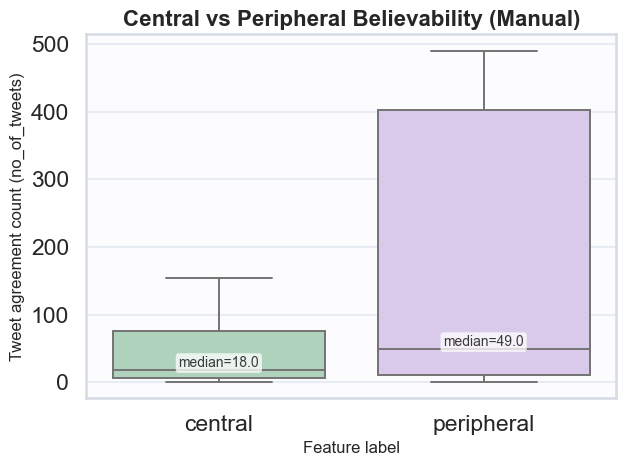

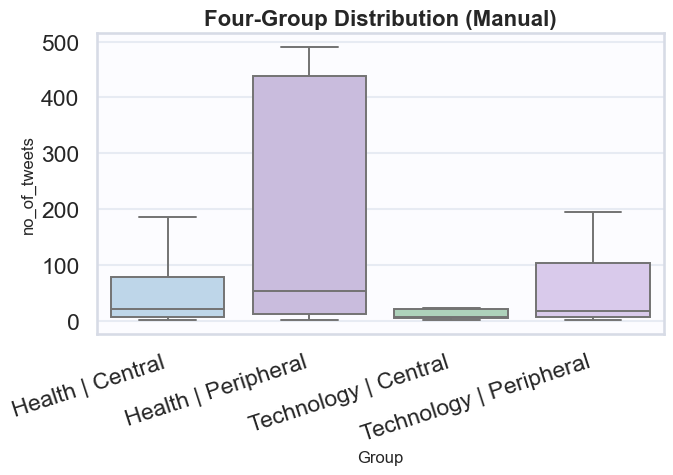

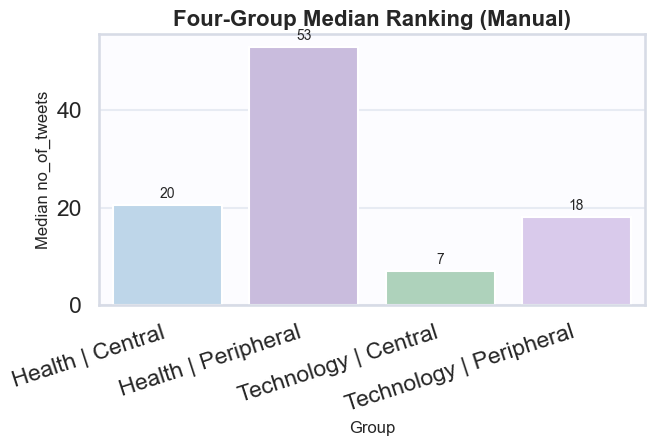

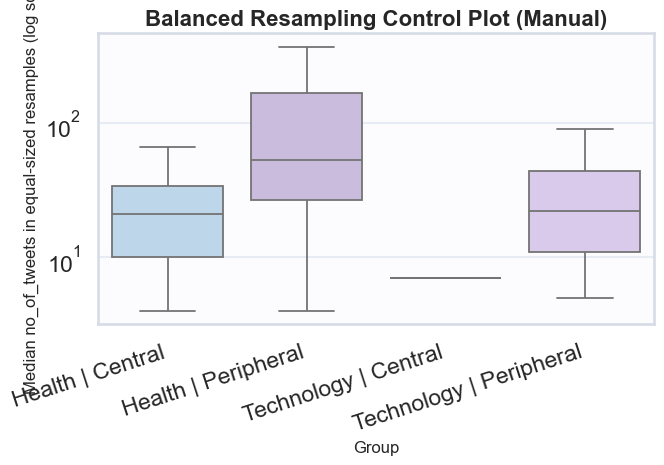

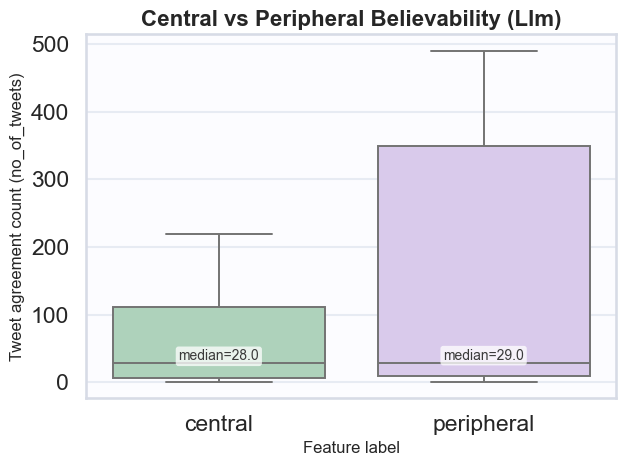

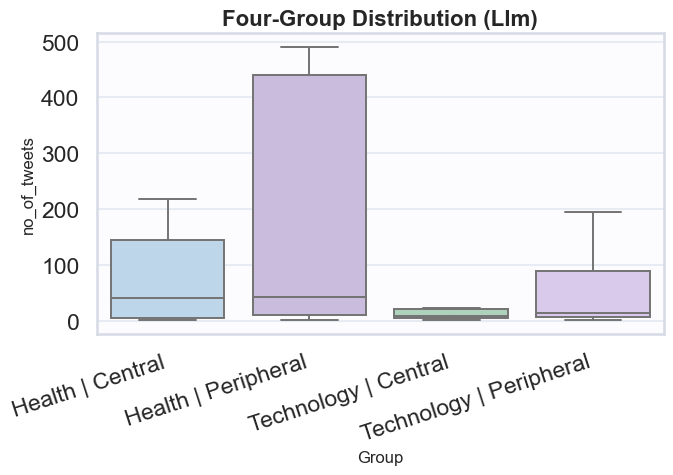

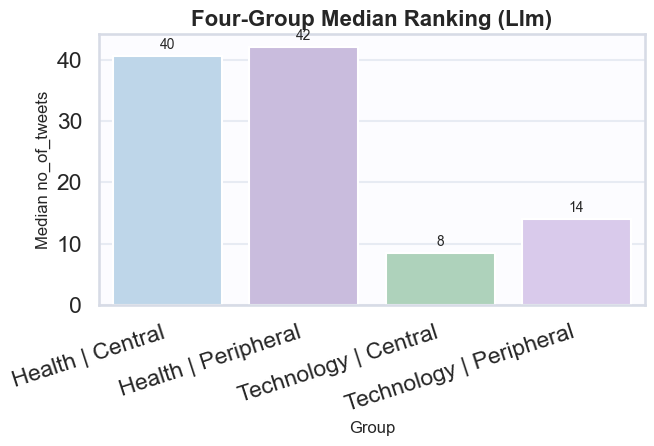

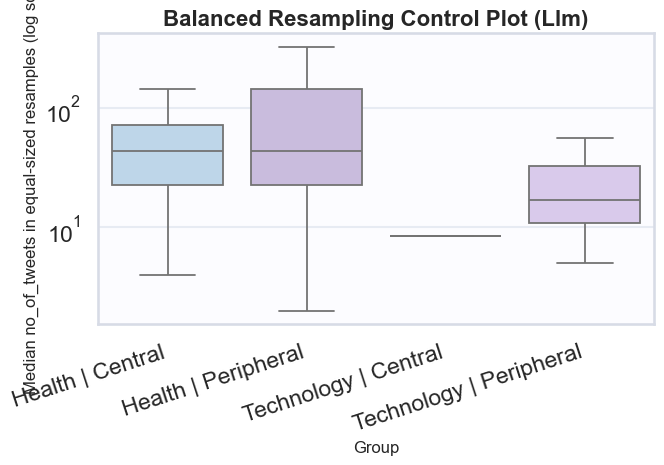

In [7]:
if HAS_PLOTTING:
    for dataset_name, results in [('manual', manual_results), ('llm', classified_results)]:
        plt.figure(figsize=(6.6, 5.0))
        ax = sns.boxplot(data=results['analysis_df'], x='framework_label', y='no_of_tweets', order=['central', 'peripheral'], palette={'central': PALETTE['framework1_feature1'], 'peripheral': PALETTE['framework1_feature2']}, showfliers=False, linewidth=1.4)
        medians = results['analysis_df'].groupby('framework_label')['no_of_tweets'].median().reindex(['central', 'peripheral'])
        for idx, value in enumerate(medians):
            ax.text(idx, value, f'median={value:.1f}', ha='center', va='bottom', fontsize=10, color='#3A3A3A', bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.75))
        plt.title(f'Central vs Peripheral Believability ({dataset_name.title()})')
        plt.xlabel('Feature label')
        plt.ylabel('Tweet agreement count (no_of_tweets)')
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(7.1, 5.1))
        sns.boxplot(data=results['analysis_df'], x='topic_framework', y='no_of_tweets', order=['Health | Central', 'Health | Peripheral', 'Technology | Central', 'Technology | Peripheral'], palette=COMBO_PALETTE, showfliers=False, linewidth=1.4)
        plt.title(f'Four-Group Distribution ({dataset_name.title()})')
        plt.xlabel('Group')
        plt.ylabel('no_of_tweets')
        plt.xticks(rotation=18, ha='right')
        plt.tight_layout()
        plt.show()

        ranking = results['summary_topic_framework'].reset_index()[['topic_framework', 'median']]
        ranking['topic_framework'] = pd.Categorical(ranking['topic_framework'], categories=['Health | Central', 'Health | Peripheral', 'Technology | Central', 'Technology | Peripheral'], ordered=True)
        ranking = ranking.sort_values('topic_framework')
        plt.figure(figsize=(6.9, 4.8))
        sns.barplot(data=ranking, x='topic_framework', y='median', palette=COMBO_PALETTE)
        plt.title(f'Four-Group Median Ranking ({dataset_name.title()})')
        plt.xlabel('Group')
        plt.ylabel('Median no_of_tweets')
        plt.xticks(rotation=18, ha='right')
        ax = plt.gca()
        for container in ax.containers:
            ax.bar_label(container, fmt='%.0f', padding=3, fontsize=10)
        plt.tight_layout()
        plt.show()

        if len(results['balanced_resamples']):
            plt.figure(figsize=(7.0, 5.0))
            sns.boxplot(data=results['balanced_resamples'], x='topic_framework', y='median_tweets', order=['Health | Central', 'Health | Peripheral', 'Technology | Central', 'Technology | Peripheral'], palette=COMBO_PALETTE, showfliers=False, linewidth=1.3)
            plt.title(f'Balanced Resampling Control Plot ({dataset_name.title()})')
            plt.xlabel('Group')
            plt.ylabel('Median no_of_tweets in equal-sized resamples (log scale)')
            plt.yscale('log')
            plt.xticks(rotation=18, ha='right')
            plt.tight_layout()
            plt.show()
        else:
            print(f"Balanced resampling plot skipped for {dataset_name}.")
else:
    print(f'Plotting skipped: {PLOTTING_ERROR}')
